In [20]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
demo_data = pd.read_csv("/home/zachkaras/fmri_model/master-survey-data.csv")
demo_data['years_experience'] = demo_data['semesters_experience'] / 2
demo_data['code_more_structured'] = demo_data['Code_more_structured'].map({'X': 0, 'Y': 1})
demo_data = demo_data.set_index('id')
print(demo_data[['age', 'GPA', 'years_experience']].describe())
print("\nCode_more_structured value counts (X=0, Y=1):")
print(demo_data['code_more_structured'].value_counts(dropna=False))

In [23]:
with open('typing_counts.pkl', 'rb') as f:
    typing_counts = pickle.load(f)

In [33]:

# Add keystroke-based variables to demo_data (separately for code and prose)
for pid_str, tasks in typing_counts.items():
    pid = int(pid_str)
    if pid not in demo_data.index:
        continue
    for task in ['code', 'prose']:
        try:
            total_keys = tasks[task]['total_keys_pressed']
        except:
            print(f"No {task} task for {pid}.")
            continue
        total_backspaces = tasks[task]['total_backspaces']
        demo_data.loc[pid, f'{task}_total_keystrokes'] = total_keys
        demo_data.loc[pid, f'{task}_editing_rate'] = total_backspaces / total_keys if total_keys > 0 else float('nan')

print(demo_data[['code_total_keystrokes', 'code_editing_rate', 'prose_total_keystrokes', 'prose_editing_rate']].describe())


No prose task for 101.
No code task for 130.
       code_total_keystrokes  code_editing_rate  prose_total_keystrokes  \
count              24.000000          24.000000               24.000000   
mean              942.416667           0.185332             2205.458333   
std               191.531792           0.057232              679.033327   
min               607.000000           0.088419              995.000000   
25%               813.750000           0.147056             1685.500000   
50%               946.500000           0.182496             2059.500000   
75%              1048.000000           0.220574             2679.750000   
max              1283.000000           0.341716             3459.000000   

       prose_editing_rate  
count           24.000000  
mean             0.088763  
std              0.055895  
min              0.026935  
25%              0.061129  
50%              0.071645  
75%              0.093025  
max              0.299497  


In [ ]:
# from scipy import stats

# def find_cutoff(vec, threshold=10**4):
#     copy = vec.copy()
#     copy.sort()
#     return copy[-threshold - 1]

# best_models = ['code-deepseek_6b-ndelays_4-look_ahead_by_10',
#             #    'code-codegemma_7b-ndelays_4-look_ahead_by_10',
#             #    'code-codegemma_7b-ndelays_16-look_ahead_by_0',
#             #    'prose-codegemma_7b-ndelays_10-look_ahead_by_5',
#             #    'prose-deepseek_6b-ndelays_20-look_ahead_by_10'
#                 'prose-deepseek_6b-ndelays_4-look_ahead_by_10',
#             ]

# participant_base_path = "/data/zachkaras/fmri_model_data/ridge_regression_pca_params"
# participants = os.listdir(participant_base_path)

# # participant_means[model][layer_num][participant_id] = mean z-scored correlation
# participant_means = {}

# for m in best_models:
#     parts = m.split('-')
#     task, model, delays, look_ahead = parts[0], parts[1], parts[2], parts[3]
#     participant_means[m] = {}

#     for p in participants:
#         files = os.listdir(f"{participant_base_path}/{p}")
#         pattern = f"{model}-{task}-{look_ahead}-{delays}"
#         best_files = [f for f in files if re.search(pattern, f) and f.endswith('correlations.pkl') and not re.search('regress', f)]

#         for bf in best_files:
#             layer_num = int(re.search(r'layer_(\d+)', bf).group(1))
#             if layer_num not in participant_means[m]:
#                 participant_means[m][layer_num] = {}

#             with open(f"{participant_base_path}/{p}/{bf}", 'rb') as f:
#                 corrs = pickle.load(f)

#             z = np.arctanh(corrs)
#             cutoff = find_cutoff(z)
#             top_vals = z[np.where(z > cutoff)[0]]
#             participant_means[m][layer_num][int(p)] = float(np.mean(top_vals))

# print("Done. Models:", list(participant_means.keys()))

Done. Models: ['code-deepseek_6b-ndelays_4-look_ahead_by_10', 'code-codegemma_7b-ndelays_4-look_ahead_by_10', 'code-codegemma_7b-ndelays_16-look_ahead_by_0', 'prose-codegemma_7b-ndelays_10-look_ahead_by_5', 'prose-deepseek_6b-ndelays_20-look_ahead_by_10']


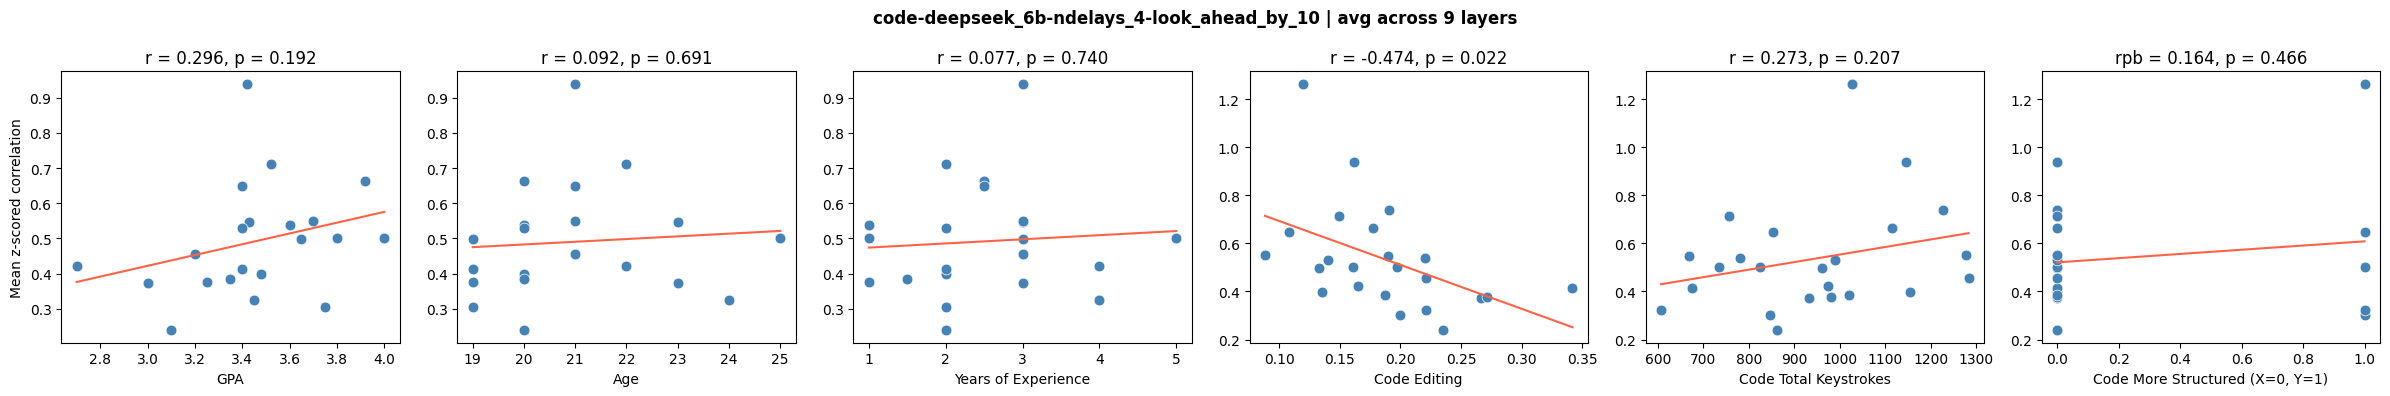

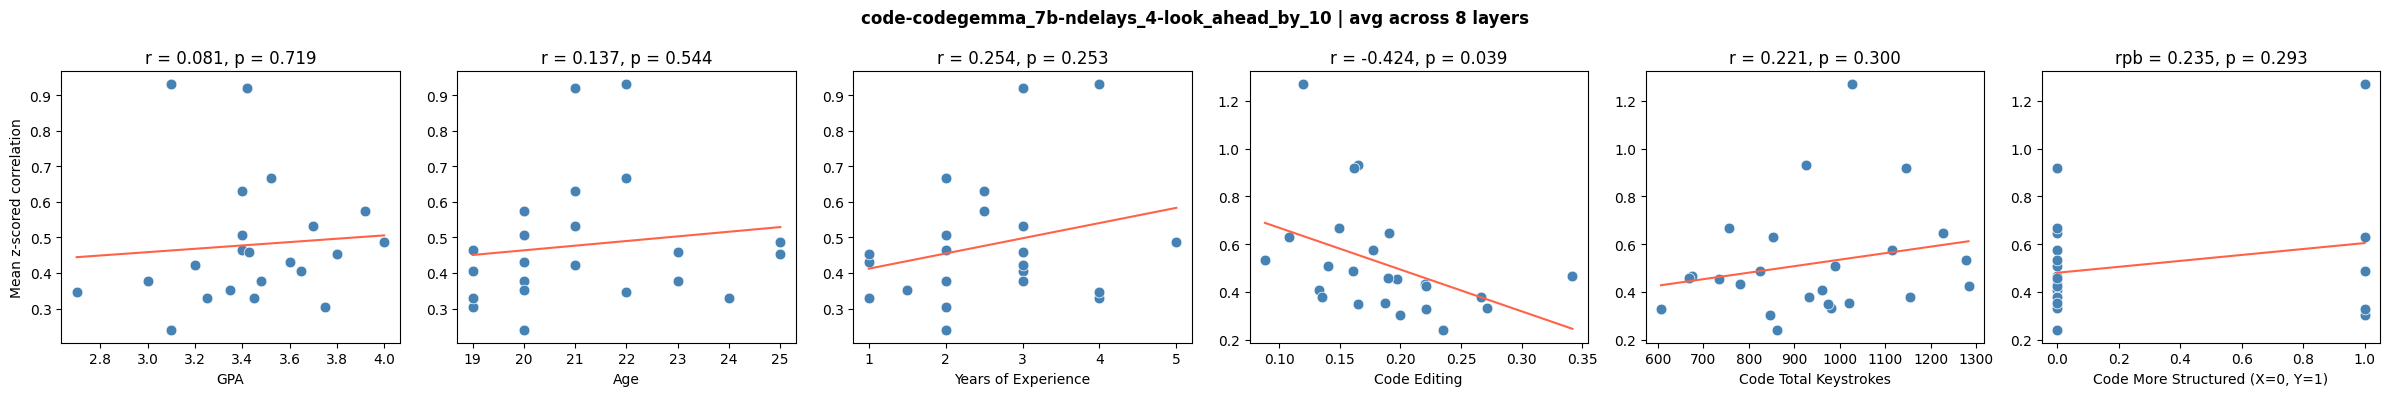

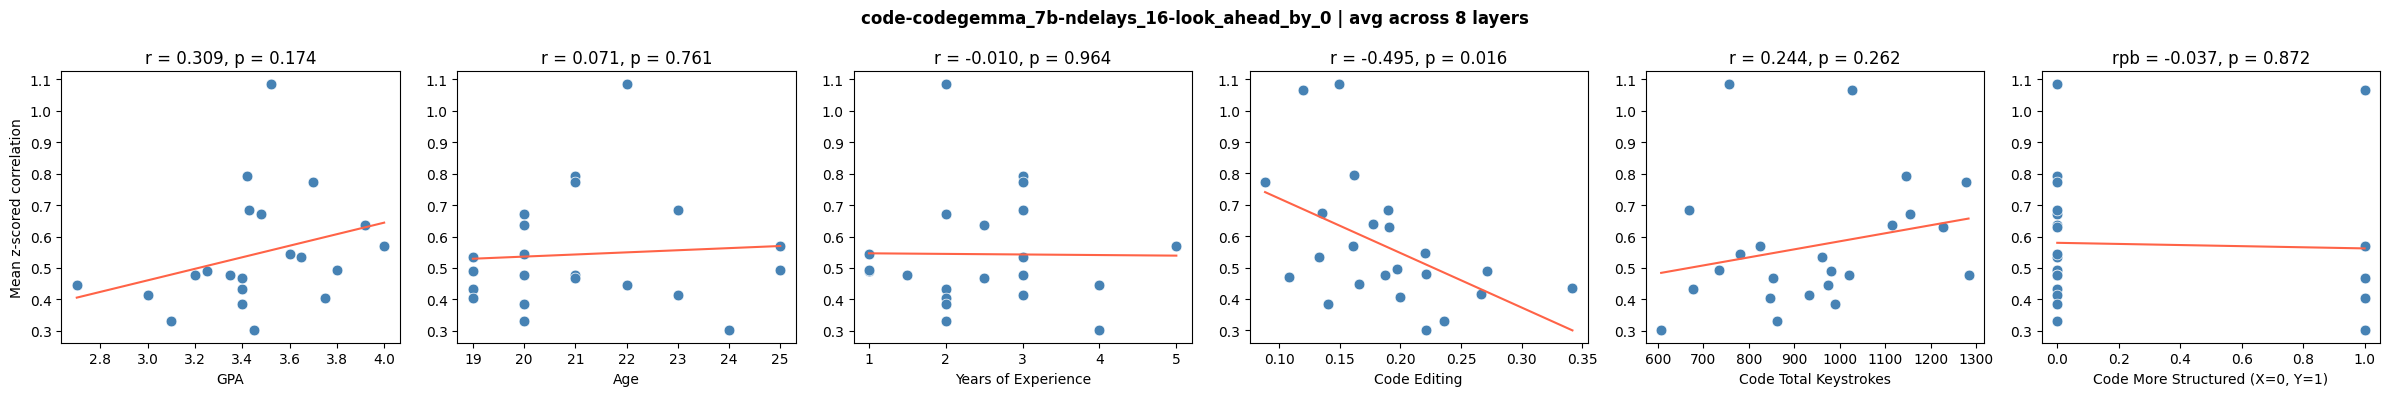

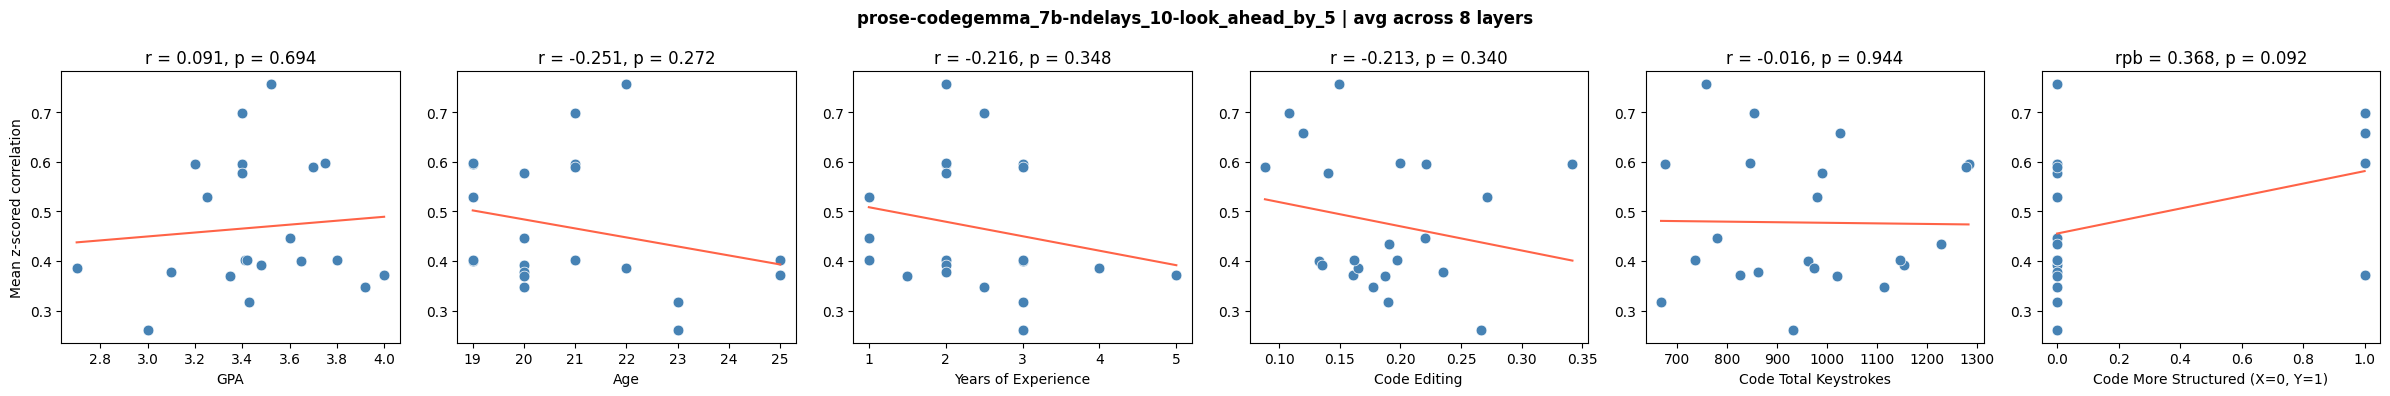

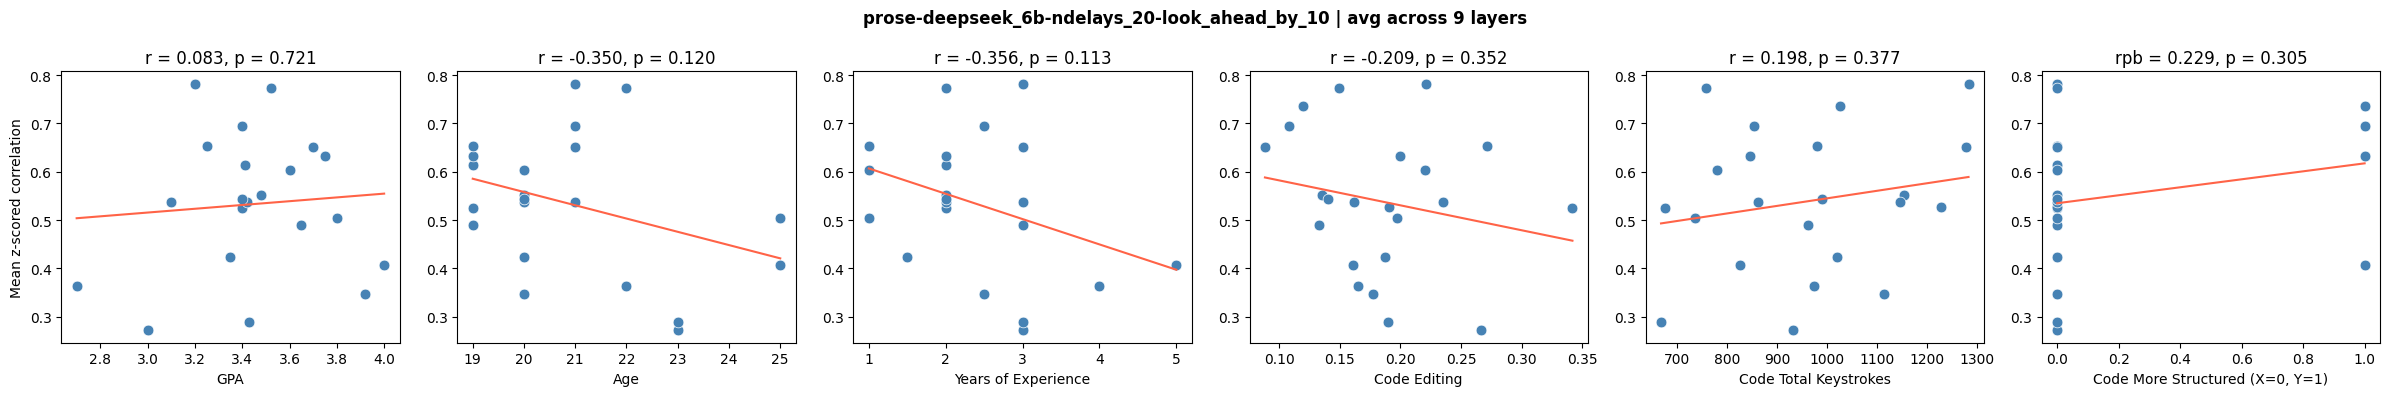

In [ ]:

# TODO - narrow down variables of interst
variables = {
    'GPA': ('GPA', False),
    'Age': ('age', False),
    'Years of Experience': ('years_experience', False),
    'Code Editing': ('code_editing_rate', False),
    # 'Prose Editing': ('prose_editing_rate', False),
    'Code Total Keystrokes': ('code_total_keystrokes', False),
    # 'Prose Total Keystrokes': ('prose_total_keystrokes', False),
    'Code More Structured (X=0, Y=1)': ('code_more_structured', True),
}

for m in best_models:
    layers = sorted(participant_means[m].keys())

    # average performance across layers for each participant
    all_pids = set(pid for layer_num in layers for pid in participant_means[m][layer_num])
    layer_averaged_perf = {}
    for pid in all_pids:
        vals = [participant_means[m][layer_num][pid] for layer_num in layers if pid in participant_means[m][layer_num]]
        layer_averaged_perf[pid] = float(np.mean(vals))

    common_ids = [pid for pid in layer_averaged_perf if pid in demo_data.index]
    brain_vals = np.array([layer_averaged_perf[pid] for pid in common_ids])

    fig, axes = plt.subplots(1, len(variables), figsize=(24, 4))
    fig.suptitle(f"{m} | avg across {len(layers)} layers", fontsize=12, fontweight='bold')

    for ax, (var_label, (col, is_binary)) in zip(axes, variables.items()):
        demo_vals = demo_data.loc[common_ids, col].values.astype(float)

        mask = ~np.isnan(demo_vals)
        x, y = demo_vals[mask], brain_vals[mask]

        if is_binary:
            r, p = stats.pointbiserialr(x, y)
            corr_label = f"rpb = {r:.3f}, p = {p:.3f}"
        else:
            r, p = stats.pearsonr(x, y)
            corr_label = f"r = {r:.3f}, p = {p:.3f}"

        ax.scatter(x, y, color='steelblue', edgecolors='white', linewidths=0.5, s=60)

        m_fit, b_fit = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, m_fit * x_line + b_fit, color='tomato', linewidth=1.5)

        ax.set_xlabel(var_label)
        ax.set_ylabel('Mean z-scored correlation' if ax == axes[0] else '')
        ax.set_title(corr_label)

    plt.tight_layout()
    plt.savefig(f"results/corr_{m}_avg_layers.png", dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# TODO - compute variables of interest based on keystroke behavior
# solutions themselves - TODO - take a look at the code participants wrote

In [ ]:
### Correlation of enriched parcels with modeling performance
###     - sig. correlations will suggest that participants who are better able to be modeled have more specialized parcels
### with other variables of interest - GPA, age, years of experience, coding behavior
with open('results/participant_parcel_enrichment_results.pkl', 'rb') as f:
    test = pickle.load(f)


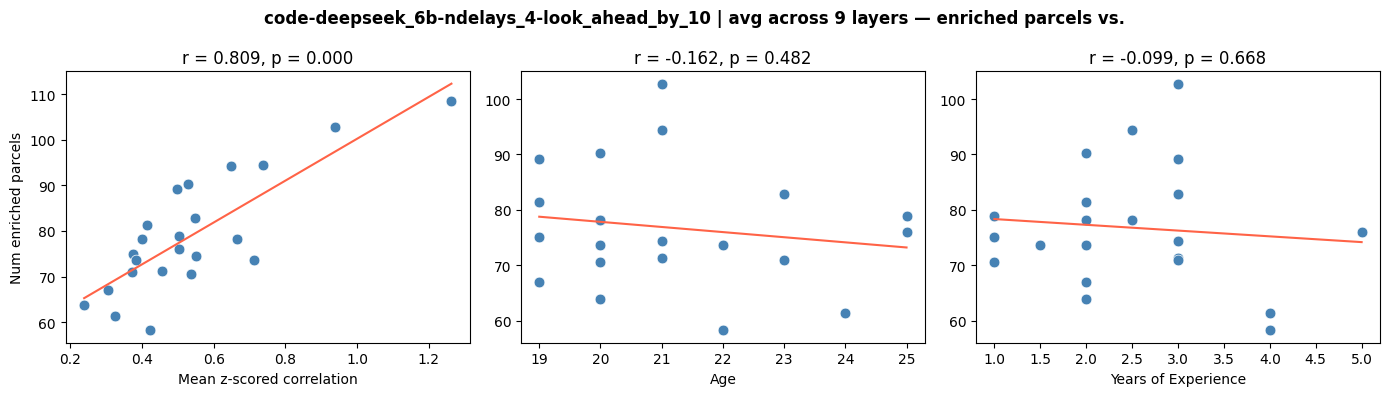

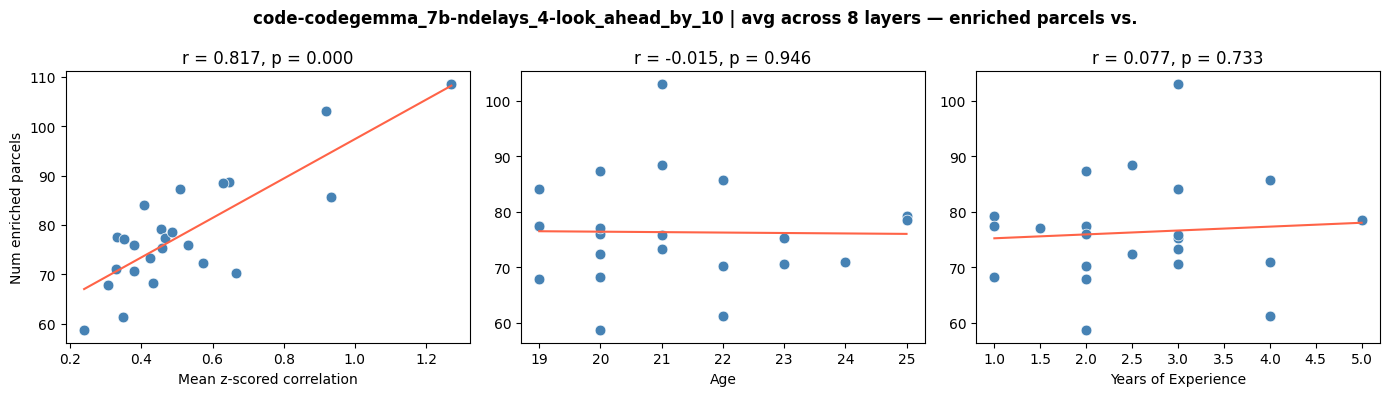

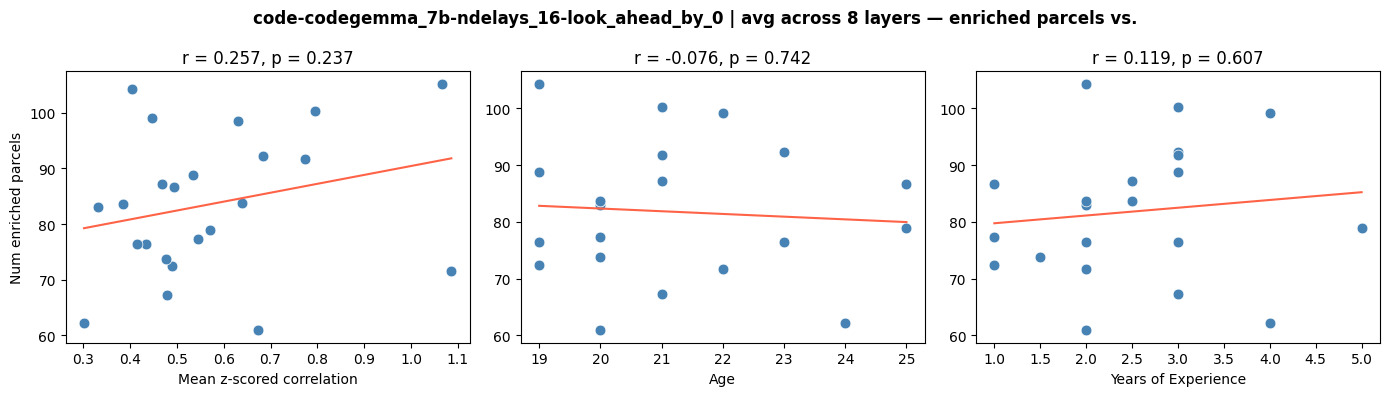

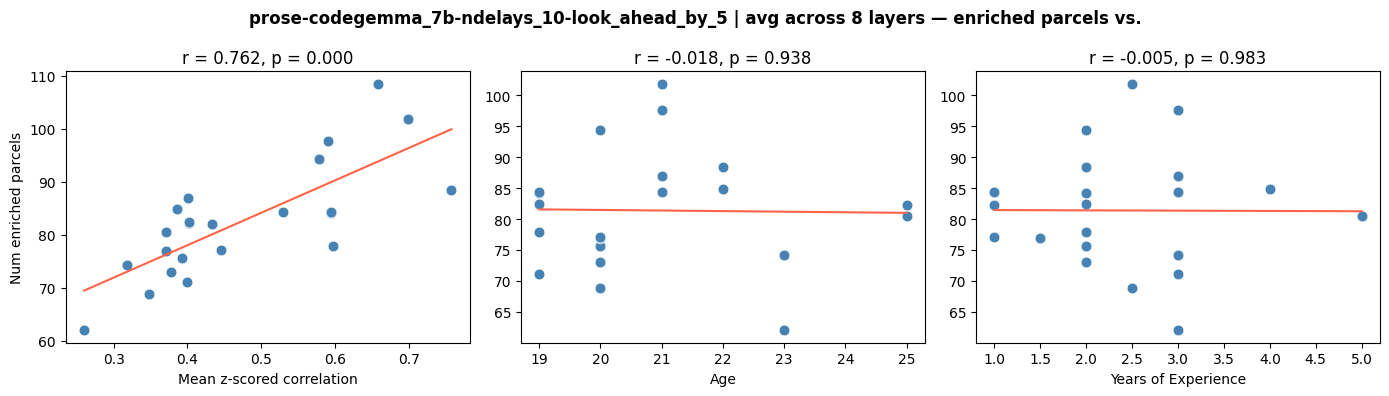

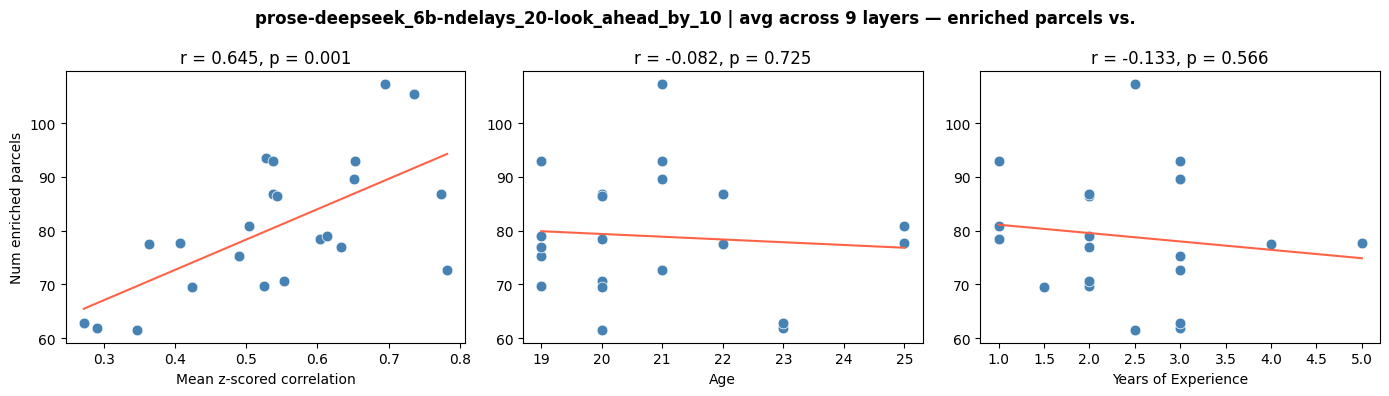

In [27]:
with open('results/participant_parcel_enrichment_results.pkl', 'rb') as f:
    enrichment_results = pickle.load(f)

enrichment_variables = {
    'Modeling Performance': None,  # filled from participant_means
    'Age': 'age',
    'Years of Experience': 'years_experience',
}

for m in best_models:
    layers = sorted(participant_means[m].keys())

    # average performance across layers for each participant
    all_perf_pids = set(pid for layer_num in layers for pid in participant_means[m][layer_num])
    layer_averaged_perf = {}
    for pid in all_perf_pids:
        vals = [participant_means[m][layer_num][pid] for layer_num in layers if pid in participant_means[m][layer_num]]
        layer_averaged_perf[pid] = float(np.mean(vals))

    # average enriched parcel counts across layers for each participant
    enrich_by_pid = {}
    for layer_num in layers:
        layer_key = f'layer_{layer_num}'
        if layer_key not in enrichment_results[m]:
            continue
        layer_enrich = enrichment_results[m][layer_key]
        for pid_str, val in layer_enrich.items():
            pid = int(pid_str)
            enrich_by_pid.setdefault(pid, []).append(val['num_sig_parcels'])

    layer_averaged_enrich = {pid: float(np.mean(vals)) for pid, vals in enrich_by_pid.items()}

    common_ids = [
        pid for pid in layer_averaged_enrich
        if pid in layer_averaged_perf and pid in demo_data.index
    ]
    enriched_vals = np.array([layer_averaged_enrich[pid] for pid in common_ids])

    fig, axes = plt.subplots(1, len(enrichment_variables), figsize=(14, 4))
    fig.suptitle(f"{m} | avg across {len(layers)} layers — enriched parcels vs.", fontsize=12, fontweight='bold')

    for ax, (var_label, col) in zip(axes, enrichment_variables.items()):
        if col is None:
            other_vals = np.array([layer_averaged_perf[pid] for pid in common_ids])
            ax.set_xlabel('Mean z-scored correlation')
        else:
            other_vals = demo_data.loc[common_ids, col].values.astype(float)
            ax.set_xlabel(var_label)

        mask = ~np.isnan(other_vals)
        x, y = other_vals[mask], enriched_vals[mask]

        r, p = stats.pearsonr(x, y)

        ax.scatter(x, y, color='steelblue', edgecolors='white', linewidths=0.5, s=60)
        m_fit, b_fit = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, m_fit * x_line + b_fit, color='tomato', linewidth=1.5)

        ax.set_ylabel('Num enriched parcels' if ax == axes[0] else '')
        ax.set_title(f"r = {r:.3f}, p = {p:.3f}")

    plt.tight_layout()
    # plt.savefig(f"results/enrichment_corr_{m}_avg_layers.png", dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# import statsmodels.api as sm
# from sklearn.preprocessing import StandardScaler

# predictor_cols = [
#     'GPA',
#     'age',
#     'years_experience',
#     'code_editing_rate',
#     'prose_editing_rate',
#     'code_total_keystrokes',
#     'prose_total_keystrokes',
#     'code_more_structured',  # binary, not standardized
#     'num_enriched_parcels',
# ]

# for m in best_models:
#     layers = sorted(participant_means[m].keys())

#     # average performance across layers
#     all_pids = set(pid for layer_num in layers for pid in participant_means[m][layer_num])
#     layer_averaged_perf = {
#         pid: float(np.mean([participant_means[m][ln][pid] for ln in layers if pid in participant_means[m][ln]]))
#         for pid in all_pids
#     }

#     # average enriched parcel counts across layers
#     enrich_by_pid = {}
#     for layer_num in layers:
#         layer_key = f'layer_{layer_num}'
#         if layer_key not in enrichment_results[m]:
#             continue
#         for pid_str, val in enrichment_results[m][layer_key].items():
#             enrich_by_pid.setdefault(int(pid_str), []).append(val['num_sig_parcels'])
#     layer_averaged_enrich = {pid: float(np.mean(vals)) for pid, vals in enrich_by_pid.items()}

#     # build dataframe aligned on common participants
#     common_ids = [pid for pid in layer_averaged_perf if pid in demo_data.index]
#     df_model = demo_data.loc[common_ids, [c for c in predictor_cols if c != 'num_enriched_parcels']].copy()
#     df_model['num_enriched_parcels'] = [layer_averaged_enrich.get(pid, float('nan')) for pid in common_ids]
#     df_model['brain_perf'] = [layer_averaged_perf[pid] for pid in common_ids]
#     df_model = df_model.dropna()

#     # standardize continuous predictors (not the binary one)
#     continuous = [c for c in predictor_cols if c != 'code_more_structured']
#     scaler = StandardScaler()
#     df_model[continuous] = scaler.fit_transform(df_model[continuous])

#     X = sm.add_constant(df_model[predictor_cols])
#     y = df_model['brain_perf']

#     result = sm.OLS(y, X).fit()

#     print("=" * 70)
#     print(f"Model: {m}  |  N = {len(df_model)}")
#     print("=" * 70)
#     print(result.summary())
#     print()

Model: code-deepseek_6b-ndelays_4-look_ahead_by_10  |  N = 19
                            OLS Regression Results                            
Dep. Variable:             brain_perf   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     2.131
Date:                Wed, 25 Mar 2026   Prob (F-statistic):              0.138
Time:                        16:20:03   Log-Likelihood:                 19.094
No. Observations:                  19   AIC:                            -18.19
Df Residuals:                       9   BIC:                            -8.744
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------